Read data from .root file

In [1]:
import uproot 
import hist
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import itertools
import numpy as np
import pandas as pd

# Open the ROOT file and read the TTree
with uproot.open("./Outputs/L1PCA_7Li.root") as file:
    tree_RAW = file["L1PCA"].arrays(library="pd")





In [2]:
tree_RAW.describe()

,fQave,fLight_fQtotal,fThetaLight,fLight_fTL,fLight_fRawTL,fPhiLight,chargePerVoxelLight,qRatio,lastThirdQ,nVoxelsLight,zDrift
count,50378.000000,50378.000000,50378.000000,50378.000000,50378.000000,50378.000000,50378.000000,50378.000000,50378.000000,50378.000000,50378.000000
mean,1139.898071,62489.792969,79.379478,69.935265,27.429508,-6.828113,1046.319092,5.038981,39923.175781,64.882032,111.802910
std,259.177460,26137.443359,14.550879,35.027767,15.704028,95.953911,214.661194,15.889116,13118.236328,36.438700,47.429070
min,600.168396,7869.000000,5.567853,6.858390,4.142540,-178.300842,445.717163,-1.000000,-1.000000,15.000000,-5.107178
25%,945.816513,42248.500000,77.678690,41.481181,14.856227,-92.751274,892.494232,2.596933,29870.000000,37.000000,82.681967
50%,1120.062744,59258.000000,79.495930,62.935181,23.956341,-29.817823,1033.757324,3.226612,38440.000000,56.000000,109.849083
75%,1321.181854,79580.750000,81.347050,93.001791,37.362456,82.691156,1179.460297,4.524330,48475.750000,86.000000,139.131260
max,3492.918945,621177.000000,179.673141,267.095001,126.267311,176.177902,2269.250000,753.028992,275234.000000,422.000000,252.491867


In [3]:
#If qRatio has any zero values, we can replace them with a small number to avoid division by zero issues
if (tree_RAW["qRatio"] == 0).any():
    print("\nWarning: qRatio contains zero values. Replacing them with a small number to avoid division by zero issues.")
    tree_RAW["qRatio"] = tree_RAW["qRatio"].replace(0, -1)

#Drop all rows that have a value = -1.0f in any column to avoid any potential issues with them in PCA
rows_to_drop = tree_RAW[(tree_RAW == -1.0).any(axis=1)]
print("\nDropping rows with -1.0 in any column:")
print(rows_to_drop)
tree = tree_RAW[~(tree_RAW == -1.0).any(axis=1)]



Dropping rows with -1.0 in any column:
             fQave  fLight_fQtotal  fThetaLight  fLight_fTL  fLight_fRawTL  \
17     1689.243042         17988.0    86.943489   18.278233       5.227953   
21     1675.085938         22969.0    81.659157   23.202662       6.207208   
70     1415.352173         35006.0    81.012207   39.503475       9.655128   
98     1997.345581         24773.0    84.509392   21.365191       6.156339   
111    1824.686035         23606.0    79.681915   20.463890       6.406252   
...            ...             ...          ...         ...            ...   
50278  1391.884155         16678.0   116.684036   21.603777       5.369194   
50281  1197.398315         32444.0    80.051033   40.767082      10.304699   
50290  1792.761597         21151.0    84.848984   21.911737       5.553893   
50356   993.152710         42976.0    78.814316   66.724167      16.399549   
50365  1399.403931         27637.0    84.137611   31.742121       7.582845   

        fPhiLight  cha

Remove all the NaNs in the tree

In [4]:
print('Check for NaN values in normalized numeric columns:')
numeric_cols = tree.select_dtypes(include=[np.number]).columns
nan_counts = tree[numeric_cols].isna().sum()
print(nan_counts)
#Remove nans
tree = tree.dropna(subset=numeric_cols)
print('After dropping NaN values, check for NaN again:')
print(tree[numeric_cols].isna().sum())

Check for NaN values in normalized numeric columns:
fQave                  0
fLight_fQtotal         0
fThetaLight            0
fLight_fTL             0
fLight_fRawTL          0
fPhiLight              0
chargePerVoxelLight    0
qRatio                 0
lastThirdQ             0
nVoxelsLight           0
zDrift                 0
dtype: int64
After dropping NaN values, check for NaN again:
fQave                  0
fLight_fQtotal         0
fThetaLight            0
fLight_fTL             0
fLight_fRawTL          0
fPhiLight              0
chargePerVoxelLight    0
qRatio                 0
lastThirdQ             0
nVoxelsLight           0
zDrift                 0
dtype: int64


In [5]:
#Add sin and cosin of phi and theta
tree["fSinPhi"]=np.sin(tree["fPhiLight"])
tree["fCosPhi"]=np.cos(tree["fPhiLight"])
tree["fSinTheta"]=np.sin(tree["fThetaLight"])
tree["fCosTheta"]=np.cos(tree["fThetaLight"])

In [6]:
# Get all the variables squared
tree["fQave2"] = tree["fQave"] ** 2
tree["fQtotal2"] = tree["fLight_fQtotal"] ** 2
tree["fThetaLight2"] = tree["fThetaLight"] ** 2
tree["fTL2"] = tree["fLight_fTL"] ** 2
tree["fRawTL2"] = tree["fLight_fRawTL"] ** 2
tree["fPhiLight2"] = tree["fPhiLight"] ** 2
tree["chargePerVoxelLight2"] = tree["chargePerVoxelLight"] ** 2
tree["qRatio2"] = tree["qRatio"] ** 2
tree["lastThirdQ2"] = tree["lastThirdQ"] ** 2
tree["nVoxelsLight2"] = tree["nVoxelsLight"] ** 2
tree["zDrift2"] = tree["zDrift"] ** 2

tree["fCosPhi2"] = tree["fCosPhi"] ** 2
tree["fSinPhi2"] = tree["fSinPhi"] ** 2
tree["fCosTheta2"] = tree["fCosTheta"] ** 2
tree["fSinTheta2"] = tree["fSinTheta"] ** 2

In [7]:
#Get all the variables cubed
tree["fQave3"] = tree["fQave"] ** 3
tree["fQtotal3"] = tree["fLight_fQtotal"] ** 3
tree["fThetaLight3"] = tree["fThetaLight"] ** 3
tree["fTL3"] = tree["fLight_fTL"] ** 3
tree["fRawTL3"] = tree["fLight_fRawTL"] ** 3
tree["fPhiLight3"] = tree["fPhiLight"] ** 3
tree["chargePerVoxelLight3"] = tree["chargePerVoxelLight"] ** 3
tree["qRatio3"] = tree["qRatio"] ** 3
tree["lastThirdQ3"] = tree["lastThirdQ"] ** 3
tree["nVoxelsLight3"] = tree["nVoxelsLight"] ** 3
tree["zDrift3"] = tree["zDrift"] ** 3

tree["fCosPhi3"] = tree["fCosPhi"] ** 3
tree["fSinPhi3"] = tree["fSinPhi"] ** 3
tree["fCosTheta3"] = tree["fCosTheta"] ** 3
tree["fSinTheta3"] = tree["fSinTheta"] ** 3

In [8]:
# Get all the variables multiplied by each other
# Multiplication is commutative, so we generate each unordered pair once.

mul_vars = [
    "fQave", "fLight_fQtotal", "fThetaLight", "fLight_fTL", "fLight_fRawTL",
    "fPhiLight", "chargePerVoxelLight", "qRatio", "lastThirdQ", "nVoxelsLight",
    "zDrift", "fSinPhi", "fCosPhi", "fSinTheta", "fCosTheta",
]

for a, b in itertools.combinations(mul_vars, 2):
    tree[f"{a}_{b}"] = tree[a] * tree[b]

# Get all the variables divided by each other
# Division is not commutative, so we generate both ordered directions.
div_vars = [
    "fQave", "fLight_fQtotal", "fThetaLight", "fLight_fTL", "fLight_fRawTL",
    "fPhiLight", "chargePerVoxelLight", "qRatio", "lastThirdQ", "nVoxelsLight",
    "zDrift", "fSinPhi", "fCosPhi", "fSinTheta", "fCosTheta",
]

for numerator in div_vars:
    for denominator in div_vars:
        if numerator == denominator:
            continue
        column_name = f"{numerator}_{denominator}_div"
        tree[column_name] = tree[numerator] / tree[denominator]

/tmp/ipykernel_19600/2280885520.py:11: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  tree[f"{a}_{b}"] = tree[a] * tree[b]
/tmp/ipykernel_19600/2280885520.py:11: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  tree[f"{a}_{b}"] = tree[a] * tree[b]
/tmp/ipykernel_19600/2280885520.py:11: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use 

In [9]:
#Add Charge / cosTheta
tree["fChargeOverCosTheta"]=tree["fLight_fQtotal"]/np.cos(tree["fThetaLight"])

/tmp/ipykernel_19600/981613741.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  tree["fChargeOverCosTheta"]=tree["fLight_fQtotal"]/np.cos(tree["fThetaLight"])


Check for NaNs

In [10]:
# =========================
# 1. NaNs por columna
# =========================
num_cols = tree.select_dtypes(include=["number"]).columns
nan_counts = tree[num_cols].isna().sum()

print("NaN per column:")
print(nan_counts[nan_counts > 0].sort_values(ascending=False))

# =========================
# 2. filas que tienen al menos un NaN
# =========================
rows_with_nan = tree[num_cols].isna().any(axis=1)

print("\nNumber of rows with at least one NaN:")
print(rows_with_nan.sum())

print("Total rows before dropna:")
print(len(tree))

# =========================
# 3. ver proporción
# =========================
print("\nFraction of affected rows:")
print(rows_with_nan.mean())

NaN per column:
Series([], dtype: int64)

Number of rows with at least one NaN:
0
Total rows before dropna:
45961

Fraction of affected rows:
0.0


Histogram fQave_qRatio_div


Max of chargePerVoxelLight / qRatio (normalized): 4705.92
Min of chargePerVoxelLight / qRatio (normalized): 1.5807965


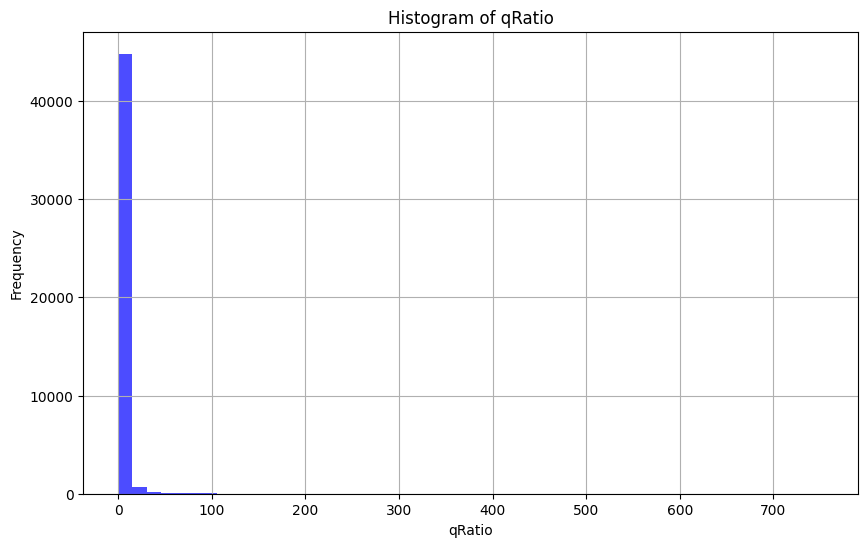


Number of rows where qRatio = -1: 0


In [11]:
#Get max and min of fQave_qRatio_div
print("\nMax of chargePerVoxelLight / qRatio (normalized):", tree["chargePerVoxelLight_qRatio_div"].max())
print("Min of chargePerVoxelLight / qRatio (normalized):", tree["chargePerVoxelLight_qRatio_div"].min())
#Histogram qRatio
plt.figure(figsize=(10, 6))
plt.hist(tree["qRatio"].dropna(), bins=50, color="blue", alpha=0.7)
plt.title("Histogram of qRatio")
plt.xlabel("qRatio")
plt.ylabel("Frequency")
plt.grid(True)
plt.show()
#Get ammount of cols qRatio = -1
print("\nNumber of rows where qRatio = -1:", (tree["qRatio"] == 0).sum())

DO THE PCA

In [12]:

# select numeric columns only
num_cols = tree.select_dtypes(include=["number"]).columns
# compute population standard deviation (ddof=0) and avoid zeros
stds = tree[num_cols].std(ddof=0)
stds = stds.replace(0, 1.0)
# create normalized copy
df_norm = tree.copy()
df_norm[num_cols] = tree[num_cols] / stds
print('Normalized numeric columns by std (ddof=0):')
print(stds)
#Print stds for chargePerVoxelLight and qRatio to check for any potential issues
print("\nStandard deviation for chargePerVoxelLight:", stds["chargePerVoxelLight"])
print("Standard deviation for qRatio:", stds["qRatio"])
#Print stds for qRatio_div cols
qratio_div_cols = [col for col in df_norm.columns if "qRatio" in col and "_div" in col]
print("\nStandard deviation for qRatio_div columns:")
for col in qratio_div_cols:
    print(f"Standard deviation for {col}:", stds[col])

# inspect first rows
print(df_norm.head())

Normalized numeric columns by std (ddof=0):
fQave                      2.367275e+02
fLight_fQtotal             2.486219e+04
fThetaLight                1.473699e+01
fLight_fTL                 3.430624e+01
fLight_fRawTL              1.523562e+01
                               ...     
fCosTheta_zDrift_div       3.601794e-01
fCosTheta_fSinPhi_div      8.994388e+01
fCosTheta_fCosPhi_div      1.044344e+02
fCosTheta_fSinTheta_div    1.019876e+02
fChargeOverCosTheta        1.906724e+07
Length: 361, dtype: float64

Standard deviation for chargePerVoxelLight: 208.7110137939453
Standard deviation for qRatio: 16.519214630126953

Standard deviation for qRatio_div columns:
Standard deviation for fQave_qRatio_div: 116.6477279663086
Standard deviation for fLight_fQtotal_qRatio_div: 15046.8857421875
Standard deviation for fThetaLight_qRatio_div: 9.596447944641113
Standard deviation for fLight_fTL_qRatio_div: 17.985668182373047
Standard deviation for fLight_fRawTL_qRatio_div: 8.253691673278809
Standard

Histogram fQave_qRatio_div variable

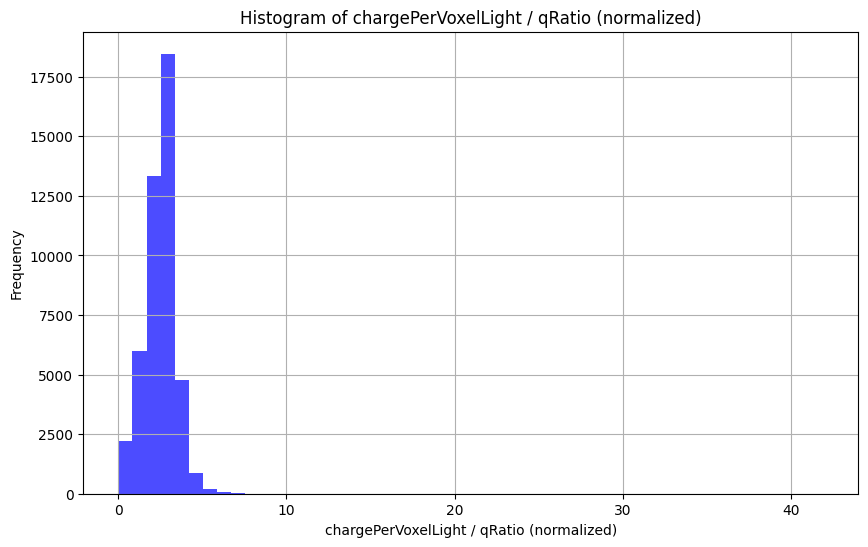

In [13]:
plt.figure(figsize=(10, 6))
plt.hist(df_norm["chargePerVoxelLight_qRatio_div"].dropna(), bins=50, color="blue", alpha=0.7)
plt.title("Histogram of chargePerVoxelLight / qRatio (normalized)")
plt.xlabel("chargePerVoxelLight / qRatio (normalized)")
plt.ylabel("Frequency")
plt.grid(True)
plt.show()

In [14]:
df_norm.describe()

,fQave,fLight_fQtotal,fThetaLight,fLight_fTL,fLight_fRawTL,fPhiLight,chargePerVoxelLight,qRatio,lastThirdQ,nVoxelsLight,...,fCosTheta_fPhiLight_div,fCosTheta_chargePerVoxelLight_div,fCosTheta_qRatio_div,fCosTheta_lastThirdQ_div,fCosTheta_nVoxelsLight_div,fCosTheta_zDrift_div,fCosTheta_fSinPhi_div,fCosTheta_fCosPhi_div,fCosTheta_fSinTheta_div,fChargeOverCosTheta
count,45961.000000,45961.000000,45961.000000,45961.000000,45961.000000,45961.000000,45961.000000,45961.000000,45961.000000,45961.000000,...,45961.000000,45961.000000,45961.000000,45961.000000,45961.000000,45961.000000,45961.000000,45961.000000,45961.000000,45961.000000
mean,4.678064,2.640178,5.370181,2.136797,1.912586,-0.013593,4.930096,0.340145,3.211568,1.939662,...,-0.004666,-0.094876,-0.128300,-0.028841,-0.004486,0.000374,0.006827,-0.003935,-0.004202,-0.003942
std,1.000011,1.000011,1.000011,1.000011,1.000011,1.000011,1.000011,1.000011,1.000011,1.000011,...,1.000011,1.000011,1.000011,1.000011,1.000011,1.000011,1.000011,1.000011,1.000011,1.000011
min,2.535272,0.579756,0.377815,0.447149,0.338574,-1.860207,2.135571,0.014389,0.092978,0.423411,...,-214.385383,-2.695588,-11.311334,-11.683446,-4.000981,-37.043671,-70.856180,-184.795898,-117.100391,-164.059855
25%,3.933649,1.858847,5.261866,1.325499,1.105015,-0.913927,4.215728,0.165802,2.459751,1.157323,...,-0.001428,-0.985869,-0.940377,-0.853851,-0.698959,-0.017638,-0.011114,-0.009545,-0.009934,-0.005502
50%,4.614336,2.505008,5.381454,1.942922,1.697508,-0.192032,4.864298,0.204563,3.106071,1.693644,...,-0.000015,-0.166969,-0.119675,-0.148304,-0.122956,-0.003118,0.000125,0.000106,-0.000187,-0.002604
75%,5.398693,3.287442,5.501915,2.797673,2.546274,0.907580,5.538409,0.287219,3.854036,2.540466,...,0.001421,0.829090,0.620617,0.765660,0.630332,0.014963,0.011107,0.009576,0.009521,0.004559
max,10.835775,24.984805,11.588317,7.785610,8.287638,1.825641,9.255449,45.585036,21.486829,10.415909,...,0.716807,2.681556,15.421979,9.952068,4.231484,136.968048,161.868885,46.775578,71.200812,42.941360


In [15]:
# Print the qRatio_div columns to check for any potential issues with them
qratio_div_cols = [col for col in df_norm.columns if "qRatio" in col and "_div" in col]
print("\nColumns containing 'qRatio' and '_div':")
print(qratio_div_cols)
#Print the first few rows of these columns to check for any potential issues
print("\nFirst few rows of qRatio_div columns:")
print(df_norm[qratio_div_cols].head())
# Print qRatio fist few rows to check for any potential issues
print("\nFirst few rows of qRatio column:")
print(df_norm["qRatio"].head())
#Print first few rows of chargePerVoxelLight
print("\nFirst few rows of chargePerVoxelLight column:")
print(df_norm["chargePerVoxelLight"].head())
# Divide manually to check for any potential issues with division by zero or very small numbers
df_norm["chargePerVoxelLight_qRatio_div_manual"] = df_norm["chargePerVoxelLight"] / df_norm["qRatio"]
print("\nFirst few rows of manually calculated chargePerVoxelLight / qRatio:")
print(df_norm["chargePerVoxelLight_qRatio_div_manual"].head())


Columns containing 'qRatio' and '_div':
['fQave_qRatio_div', 'fLight_fQtotal_qRatio_div', 'fThetaLight_qRatio_div', 'fLight_fTL_qRatio_div', 'fLight_fRawTL_qRatio_div', 'fPhiLight_qRatio_div', 'chargePerVoxelLight_qRatio_div', 'qRatio_fQave_div', 'qRatio_fLight_fQtotal_div', 'qRatio_fThetaLight_div', 'qRatio_fLight_fTL_div', 'qRatio_fLight_fRawTL_div', 'qRatio_fPhiLight_div', 'qRatio_chargePerVoxelLight_div', 'qRatio_lastThirdQ_div', 'qRatio_nVoxelsLight_div', 'qRatio_zDrift_div', 'qRatio_fSinPhi_div', 'qRatio_fCosPhi_div', 'qRatio_fSinTheta_div', 'qRatio_fCosTheta_div', 'lastThirdQ_qRatio_div', 'nVoxelsLight_qRatio_div', 'zDrift_qRatio_div', 'fSinPhi_qRatio_div', 'fCosPhi_qRatio_div', 'fSinTheta_qRatio_div', 'fCosTheta_qRatio_div']

First few rows of qRatio_div columns:
   fQave_qRatio_div  fLight_fQtotal_qRatio_div  fThetaLight_qRatio_div  \
0          4.479884                   2.356736                3.532839   
1          3.910345                   1.368368                2.52019

/tmp/ipykernel_19600/887954010.py:15: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_norm["chargePerVoxelLight_qRatio_div_manual"] = df_norm["chargePerVoxelLight"] / df_norm["qRatio"]


Check again for NaNs

In [16]:
# =========================
# 1. NaNs por columna
# =========================
nan_counts = df_norm[num_cols].isna().sum()

print("NaN per column:")
print(nan_counts[nan_counts > 0].sort_values(ascending=False))

# =========================
# 2. filas que tienen al menos un NaN
# =========================
rows_with_nan = df_norm[num_cols].isna().any(axis=1)

print("\nNumber of rows with at least one NaN:")
print(rows_with_nan.sum())

print("Total rows before dropna:")
print(len(df_norm))

# =========================
# 3. ver proporción
# =========================
print("\nFraction of affected rows:")
print(rows_with_nan.mean())

NaN per column:
Series([], dtype: int64)

Number of rows with at least one NaN:
0
Total rows before dropna:
45961

Fraction of affected rows:
0.0


Number of rows with qRatio = 0: 0


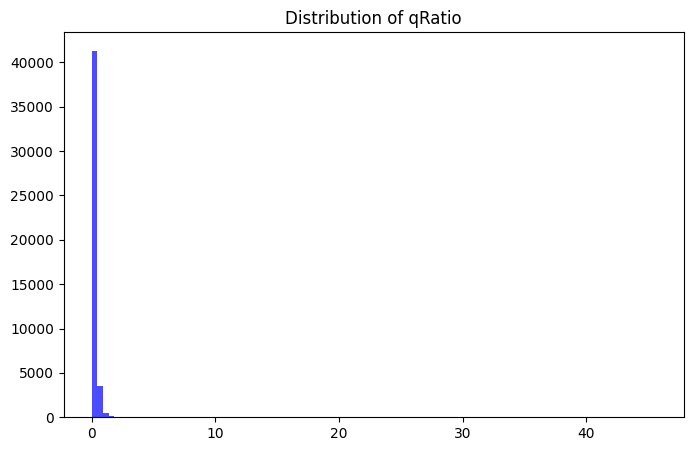

In [17]:
#plot 1d of qratio
plt.figure(figsize=(8, 5))
plt.hist(df_norm["qRatio"], bins=100, color="blue", alpha=0.7)
plt.title("Distribution of qRatio")
#check how many qratio = 0
num_zero_qratio = (df_norm["qRatio"] < 1e-9).sum()
print(f"Number of rows with qRatio = 0: {num_zero_qratio}")

In [18]:
print('Check for NaN values in normalized numeric columns:')
print(df_norm[num_cols].isna().sum())
# Remove the rows with NaN values in the numeric columns
df_norm = df_norm.dropna(subset=num_cols)
print('After dropping NaN values, check for NaN again:')
print(df_norm[num_cols].isna().sum())

Check for NaN values in normalized numeric columns:
fQave                      0
fLight_fQtotal             0
fThetaLight                0
fLight_fTL                 0
fLight_fRawTL              0
                          ..
fCosTheta_zDrift_div       0
fCosTheta_fSinPhi_div      0
fCosTheta_fCosPhi_div      0
fCosTheta_fSinTheta_div    0
fChargeOverCosTheta        0
Length: 361, dtype: int64
After dropping NaN values, check for NaN again:
fQave                      0
fLight_fQtotal             0
fThetaLight                0
fLight_fTL                 0
fLight_fRawTL              0
                          ..
fCosTheta_zDrift_div       0
fCosTheta_fSinPhi_div      0
fCosTheta_fCosPhi_div      0
fCosTheta_fSinTheta_div    0
fChargeOverCosTheta        0
Length: 361, dtype: int64


In [19]:
df_norm.describe()

,fQave,fLight_fQtotal,fThetaLight,fLight_fTL,fLight_fRawTL,fPhiLight,chargePerVoxelLight,qRatio,lastThirdQ,nVoxelsLight,...,fCosTheta_chargePerVoxelLight_div,fCosTheta_qRatio_div,fCosTheta_lastThirdQ_div,fCosTheta_nVoxelsLight_div,fCosTheta_zDrift_div,fCosTheta_fSinPhi_div,fCosTheta_fCosPhi_div,fCosTheta_fSinTheta_div,fChargeOverCosTheta,chargePerVoxelLight_qRatio_div_manual
count,45961.000000,45961.000000,45961.000000,45961.000000,45961.000000,45961.000000,45961.000000,45961.000000,45961.000000,45961.000000,...,45961.000000,45961.000000,45961.000000,45961.000000,45961.000000,45961.000000,45961.000000,45961.000000,45961.000000,45961.000000
mean,4.678064,2.640178,5.370181,2.136797,1.912586,-0.013593,4.930096,0.340145,3.211568,1.939662,...,-0.094876,-0.128300,-0.028841,-0.004486,0.000374,0.006827,-0.003935,-0.004202,-0.003942,22.301605
std,1.000011,1.000011,1.000011,1.000011,1.000011,1.000011,1.000011,1.000011,1.000011,1.000011,...,1.000011,1.000011,1.000011,1.000011,1.000011,1.000011,1.000011,1.000011,1.000011,8.888915
min,2.535272,0.579756,0.377815,0.447149,0.338574,-1.860207,2.135571,0.014389,0.092978,0.423411,...,-2.695588,-11.311334,-11.683446,-4.000981,-37.043671,-70.856180,-184.795898,-117.100391,-164.059855,0.125118
25%,3.933649,1.858847,5.261866,1.325499,1.105015,-0.913927,4.215728,0.165802,2.459751,1.157323,...,-0.985869,-0.940377,-0.853851,-0.698959,-0.017638,-0.011114,-0.009545,-0.009934,-0.005502,17.445000
50%,4.614336,2.505008,5.381454,1.942922,1.697508,-0.192032,4.864298,0.204563,3.106071,1.693644,...,-0.166969,-0.119675,-0.148304,-0.122956,-0.003118,0.000125,0.000106,-0.000187,-0.002604,23.039904
75%,5.398693,3.287442,5.501915,2.797673,2.546274,0.907580,5.538409,0.287219,3.854036,2.540466,...,0.829090,0.620617,0.765660,0.630332,0.014963,0.011107,0.009576,0.009521,0.004559,27.015311
max,10.835775,24.984805,11.588317,7.785610,8.287638,1.825641,9.255449,45.585036,21.486829,10.415909,...,2.681556,15.421979,9.952068,4.231484,136.968048,161.868885,46.775578,71.200812,42.941360,372.467661


In [20]:
#Drop all columns that have qRatio in the name to avoid any potential issues with them in PCA
#qratio_cols = [col for col in df_norm.columns if "qRatio" in col]
#print("\nDropping columns containing 'qRatio':")
#print(qratio_cols)
#df_norm = df_norm.drop(columns=qratio_cols)

In [35]:
n_comp = 5
pca=PCA(n_components=n_comp)
num_cols = df_norm.select_dtypes(include=["number"]).columns
pca.fit(df_norm[num_cols])
print('Explained variance ratio:', pca.explained_variance_ratio_)
print('Principal components:\n', pca.components_)


Explained variance ratio: [0.25416701 0.10980967 0.04498576 0.04059554 0.04038657]
Principal components:
 [[-5.71314291e-02  7.38367190e-02 -1.77792966e-02 ... -6.67216102e-05
  -1.84455995e-04  7.51987671e-01]
 [ 6.43523934e-02 -7.73524136e-02  1.64124116e-02 ... -1.29420274e-03
   1.14686492e-04  5.54396641e-01]
 [-3.11893627e-02  2.07107744e-02 -2.60549488e-02 ... -2.05447521e-03
  -4.59821406e-04  7.48972422e-02]
 [-1.48068232e-03 -2.55859147e-05  5.85672713e-03 ... -7.09962916e-04
  -1.75655846e-03 -4.44300707e-02]
 [ 2.92002972e-04  3.05807055e-03 -1.48261102e-02 ... -1.17936332e-03
   1.43427667e-03  5.98427464e-02]]


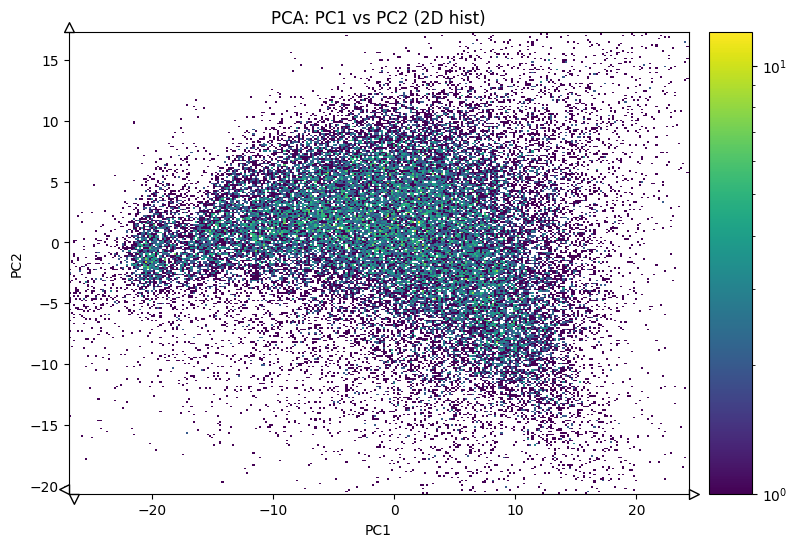

In [36]:
# 2D histogram of the first two PCA components using `hist`
pca_result = pca.transform(df_norm[num_cols])
pc1 = pca_result[:, 0]
pc2 = pca_result[:, 1]
# use robust percentile-driven ranges to avoid extreme outliers
xmin, xmax = np.percentile(pc1, [0.5, 99.5])
ymin, ymax = np.percentile(pc2, [0.5, 99.5])
# build a 2D hist with the `hist` package
h2 = hist.Hist(hist.axis.Regular(300, xmin, xmax, name="PC1"),
               hist.axis.Regular(300, ymin, ymax, name="PC2"))
h2.fill(PC1=pc1, PC2=pc2)
# draw with matplotlib (use pcolormesh from the histogram edges and values)
fig, ax = plt.subplots(figsize=(8,6))
h2.plot(ax=ax,norm=mcolors.LogNorm(), cmap='viridis')

ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.set_title('PCA: PC1 vs PC2 (2D hist)')
plt.show()

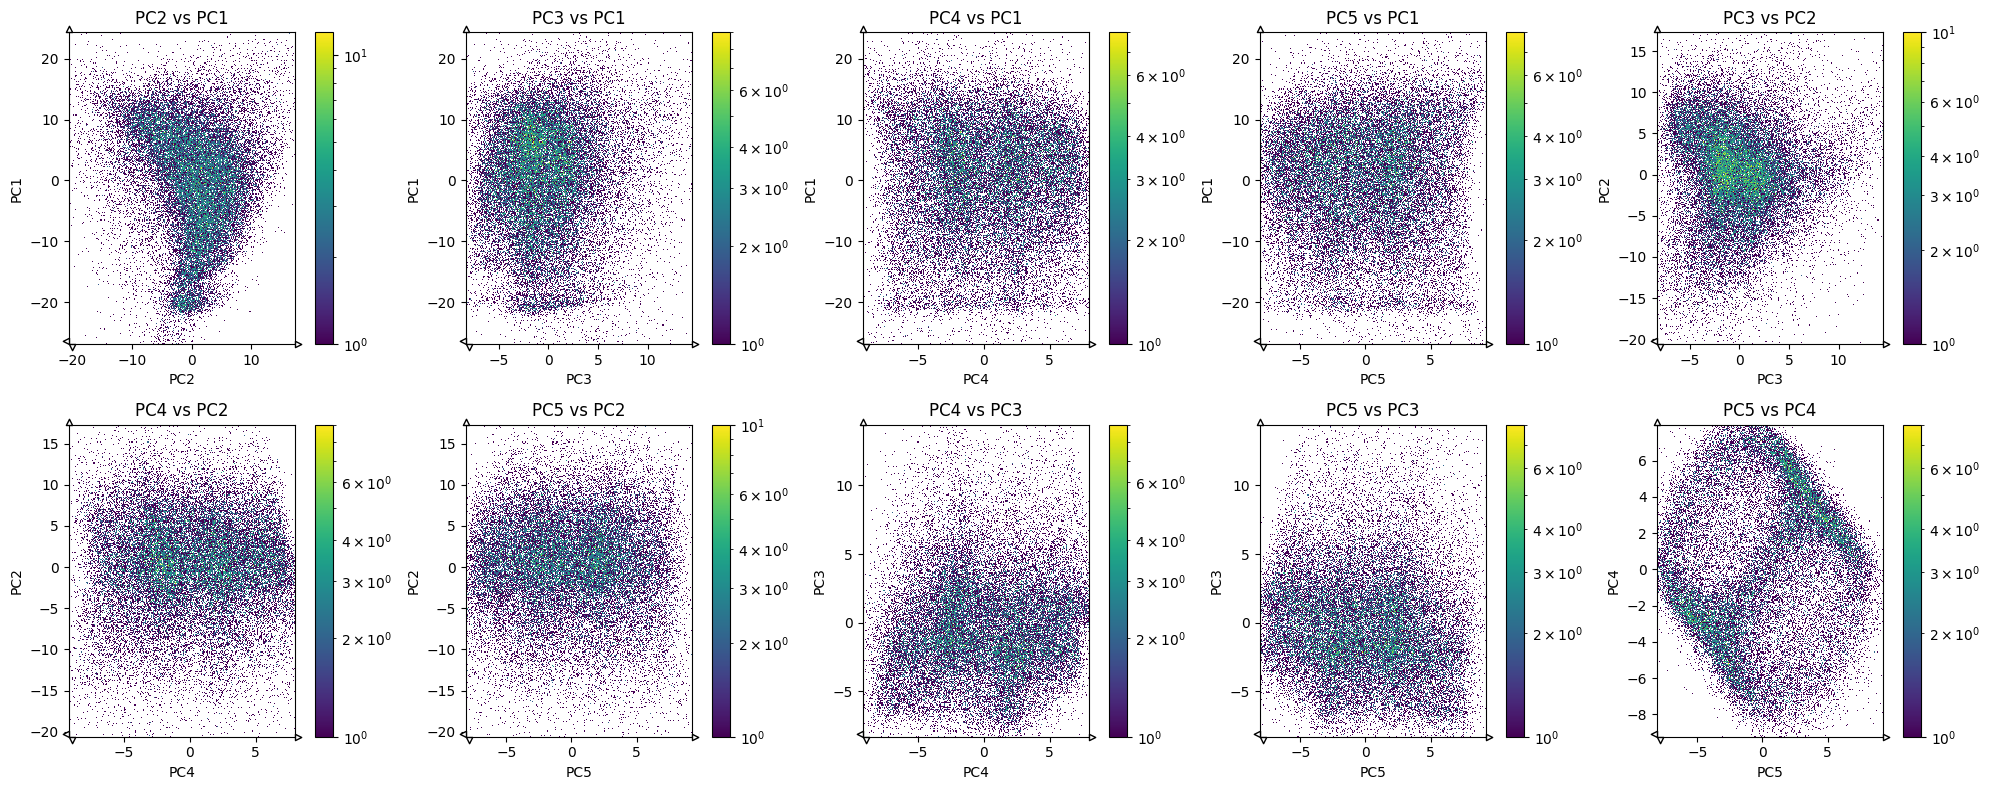

In [37]:
# PCA transform
pca_result = pca.transform(df_norm[num_cols])

pairs = list(itertools.combinations(range(n_comp), 2))

# layout (2 filas x 5 columnas = 10 plots)
fig, axes = plt.subplots(2, 5, figsize=(20, 8))

for ax, (i, j) in zip(axes.flatten(), pairs):
    
    pcx = pca_result[:, j]
    pcy = pca_result[:, i]
    
    # percentiles robustos
    xmin, xmax = np.percentile(pcx, [0.5, 99.5])
    ymin, ymax = np.percentile(pcy, [0.5, 99.5])
    
    # histograma 2D
    h2 = hist.Hist(
        hist.axis.Regular(300, xmin, xmax, name=f"PC{j+1}"),
        hist.axis.Regular(300, ymin, ymax, name=f"PC{i+1}")
    )
    
    h2.fill(**{f"PC{j+1}": pcx, f"PC{i+1}": pcy})
    
    # plot
    h2.plot(ax=ax, norm=mcolors.LogNorm(), cmap='viridis')
    
    ax.set_xlabel(f'PC{j+1}')
    ax.set_ylabel(f'PC{i+1}')
    ax.set_title(f'PC{j+1} vs PC{i+1}')

plt.tight_layout()
plt.show()

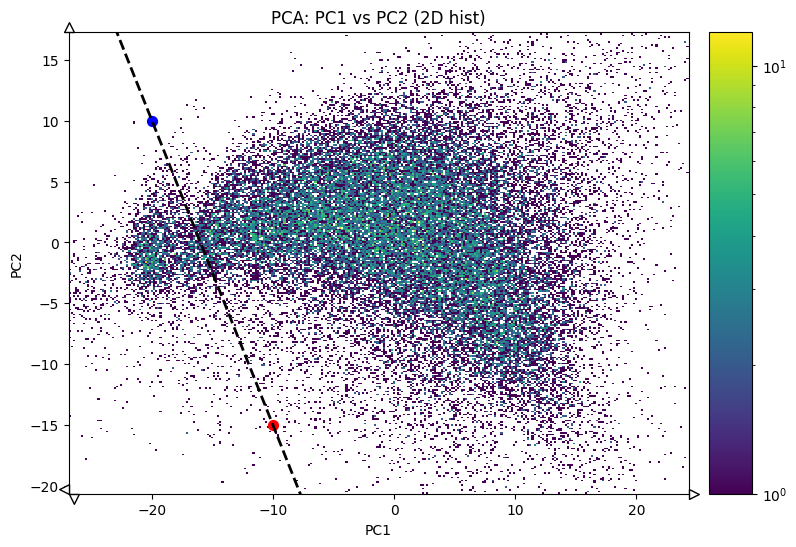

In [41]:
# 2D histogram of the two best PCA components using `hist`
pca_result = pca.transform(df_norm[num_cols])
pc1 = pca_result[:, 0]
pc2 = pca_result[:, 1]
# use robust percentile-driven ranges to avoid extreme outliers
xmin, xmax = np.percentile(pc1, [0.5, 99.5])
ymin, ymax = np.percentile(pc2, [0.5, 99.5])
# build a 2D hist with the `hist` package
h2 = hist.Hist(hist.axis.Regular(300, xmin, xmax, name="PC1"),
               hist.axis.Regular(300, ymin, ymax, name="PC2"))
h2.fill(PC1=pc1, PC2=pc2)
# draw with matplotlib (use pcolormesh from the histogram edges and values)
fig, ax = plt.subplots(figsize=(8,6))
h2.plot(ax=ax,norm=mcolors.LogNorm(), cmap='viridis')

# 🔴 puntos
p1 = (-10, -15)
p2 = (-20, 10)

ax.scatter(*p1, color='red', s=50, label='Point 1')
ax.scatter(*p2, color='blue', s=50, label='Point 2')


# calcular recta
x1, y1 = p1
x2, y2 = p2

m = (y2 - y1) / (x2 - x1)
b = y1 - m * x1

# extender al rango del histograma
x_line = np.linspace(xmin, xmax, 500)
y_line = m * x_line + b

ax.plot(x_line, y_line, color='black', linewidth=2, linestyle='--')

ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.set_title('PCA: PC1 vs PC2 (2D hist)')
plt.show()

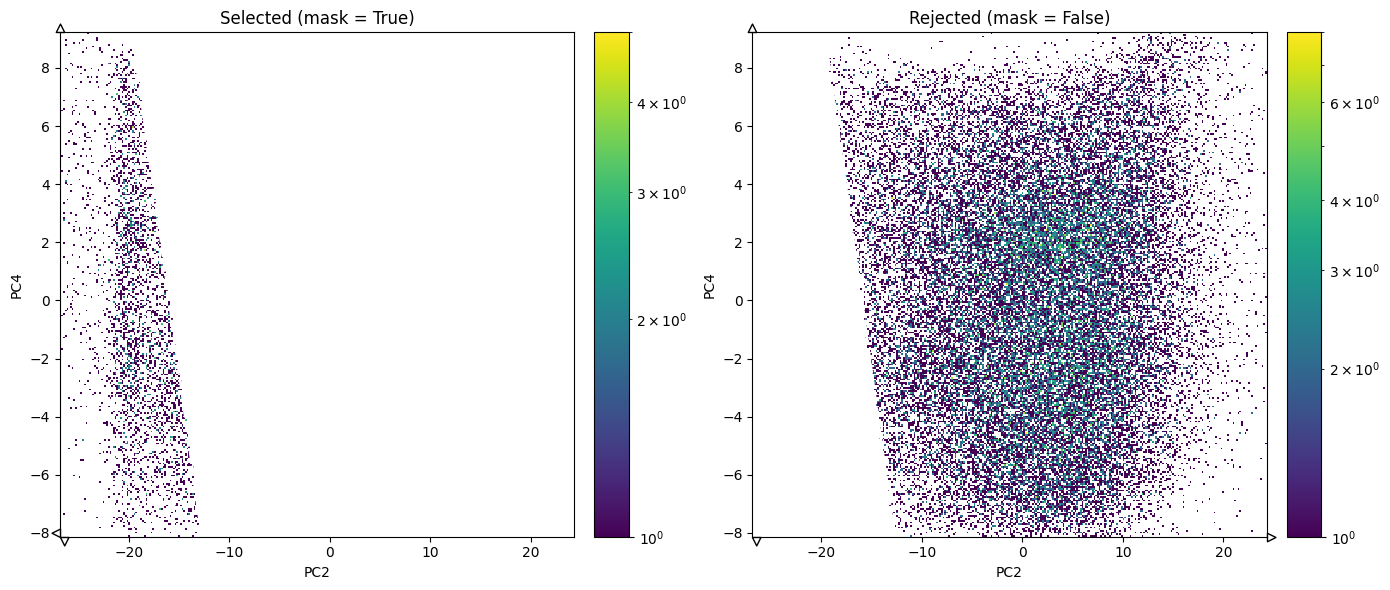

Selected: (3511, 362)
Rejected: (42450, 362)


In [42]:
# =========================
# PCA components
# =========================
pc1 = pca_result[:, 0]  # PC2
pc2 = pca_result[:, 4]  # PC4

# =========================
# recta definida por 2 puntos
# =========================

x1, y1 = p1
x2, y2 = p2

dx = x2 - x1
dy = y2 - y1

mask = (pc1 - x1)*dy - (pc2 - y1)*dx < 0

# invertir si hace falta
# mask = ~mask

# =========================
# rangos comunes (importante)
# =========================
xmin, xmax = np.percentile(pc1, [0.5, 99.5])
ymin, ymax = np.percentile(pc2, [0.5, 99.5])

# =========================
# histogramas separados
# =========================
h_sel = hist.Hist(
    hist.axis.Regular(300, xmin, xmax, name="PC1"),
    hist.axis.Regular(300, ymin, ymax, name="PC2")
)

h_bkg = hist.Hist(
    hist.axis.Regular(300, xmin, xmax, name="PC1"),
    hist.axis.Regular(300, ymin, ymax, name="PC2")
)

h_sel.fill(PC1=pc1[mask], PC2=pc2[mask])
h_bkg.fill(PC1=pc1[~mask], PC2=pc2[~mask])

# =========================
# plot
# =========================
fig, ax = plt.subplots(1, 2, figsize=(14, 6))

# --- seleccionados ---
h_sel.plot(ax=ax[0], norm=mcolors.LogNorm(), cmap='viridis')
ax[0].set_title('Selected (mask = True)')
ax[0].set_xlabel('PC2')
ax[0].set_ylabel('PC4')

# recta encima
x_line = np.linspace(xmin, xmax, 500)
if dx != 0:
    m = dy / dx
    b = y1 - m * x1
    y_line = m * x_line + b
    ax[0].plot(x_line, y_line, 'w--', linewidth=2)
else:
    ax[0].axvline(x=x1, color='w', linestyle='--', linewidth=2)

# --- fondo ---
h_bkg.plot(ax=ax[1], norm=mcolors.LogNorm(), cmap='viridis')
ax[1].set_title('Rejected (mask = False)')
ax[1].set_xlabel('PC2')
ax[1].set_ylabel('PC4')

if dx != 0:
    ax[1].plot(x_line, y_line, 'w--', linewidth=2)
else:
    ax[1].axvline(x=x1, color='w', linestyle='--', linewidth=2)

plt.tight_layout()
plt.show()

# =========================
# output data
# =========================
selected_data = df_norm[mask]
rejected_data = df_norm[~mask]

print("Selected:", selected_data.shape)
print("Rejected:", rejected_data.shape)

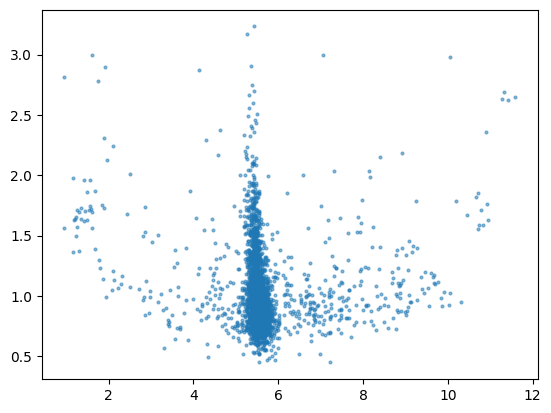

In [43]:
#Plot the kinematics (Theta vs TL) for the selected data
plt.plot(selected_data["fThetaLight"], selected_data["fLight_fTL"], 'o', markersize=2, alpha=0.5)

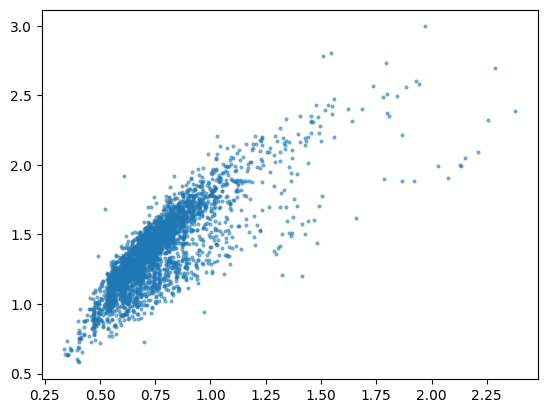

In [44]:
# Plot the PID
plt.plot(selected_data["fLight_fRawTL"], selected_data["fLight_fQtotal"], 'o', markersize=2, alpha=0.5)